## Setup

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Import evaluation functions
from rsm_evaluation import (
    # Retrieval tests
    FactRetrievalDataset,
    evaluate_retrieval_at_distance,
    
    # Chain-of-thought tests
    ChainOfThoughtTask,
    evaluate_cot_depth,
    
    # Ablation studies
    ablation_no_sync,
    ablation_freeze_ssm,
    ablation_vary_architecture,
    
    # Memory analysis
    MemoryProbe,
    train_memory_probe,
    analyze_memory_retention
)

# Import model creation
from hybrid_transformer1 import create_rsm_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("✓ Evaluation functions loaded")

Device: cpu
✓ Evaluation functions loaded


## Load Trained Model from Checkpoint

Loading the model you trained on Shakespeare!

In [15]:
from hybrid_transformer1 import load_checkpoint

# Load trained checkpoint
checkpoint_path = 'checkpoint_epoch_10.pt'

print(f"Loading checkpoint: {checkpoint_path}")
model, global_sync, config = load_checkpoint(
    filepath=checkpoint_path,
    device=device
)

print("\n✓ Trained model loaded successfully!")
print(f"  Model trained on: Shakespeare (BPE tokenization)")
print(f"  Vocabulary size: {config['vocab_size']:,}")
print(f"  Hidden size: {config['hidden_size']}")
print(f"  Num layers: {config['num_layers']}")
print(f"  Memory slots: {config['n_slots']}")

vocab_size = config['vocab_size']

Loading checkpoint: checkpoint_epoch_10.pt
✓ Checkpoint loaded from checkpoint_epoch_10.pt

✓ Trained model loaded successfully!
  Model trained on: Shakespeare (BPE tokenization)
  Vocabulary size: 50,257
  Hidden size: 256
  Num layers: 8
  Memory slots: 32
✓ Checkpoint loaded from checkpoint_epoch_10.pt

✓ Trained model loaded successfully!
  Model trained on: Shakespeare (BPE tokenization)
  Vocabulary size: 50,257
  Hidden size: 256
  Num layers: 8
  Memory slots: 32


In [16]:
# Reload the evaluation module to get latest changes
import importlib
import rsm_evaluation
importlib.reload(rsm_evaluation)

# Re-import the functions
from rsm_evaluation import (
    evaluate_retrieval_at_distance,
    evaluate_cot_depth,
    ablation_no_sync,
    analyze_memory_retention
)

print("✓ Evaluation module reloaded")

✓ Evaluation module reloaded


## Test 1: Fact Retrieval at Distance

Can the model remember facts from earlier in the sequence?

Testing fact retrieval at different distances...

Testing distance=32...
  Distance 32: 0.000 accuracy (0/20)
Testing distance=64...
  Distance 32: 0.000 accuracy (0/20)
Testing distance=64...
  Distance 64: 0.000 accuracy (0/20)
Testing distance=128...
  Distance 64: 0.000 accuracy (0/20)
Testing distance=128...
  Distance 128: 0.000 accuracy (0/20)
  Distance 128: 0.000 accuracy (0/20)


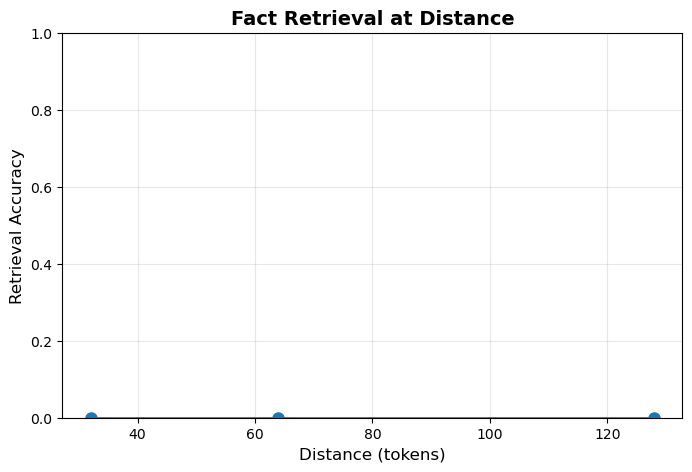


✓ Retrieval test complete
  Distance 32: 0.000 accuracy
  Distance 64: 0.000 accuracy
  Distance 128: 0.000 accuracy


In [17]:
print("Testing fact retrieval at different distances...\n")

# IMPORTANT: Model was trained with chunk_size=128, so keep sequences short
# Test at distances that fit within the model's context window
results = evaluate_retrieval_at_distance(
    model=model,
    distances=[32, 64, 128],  # Shorter distances that fit in model's window
    num_samples=20,
    device=device,
    max_seq_len=256  # Match model's positional encoding size
)

# Plot results
distances = list(results.keys())
accuracies = [results[d]['accuracy'] if isinstance(results[d], dict) else results[d] for d in distances]

plt.figure(figsize=(8, 5))
plt.plot(distances, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('Distance (tokens)', fontsize=12)
plt.ylabel('Retrieval Accuracy', fontsize=12)
plt.title('Fact Retrieval at Distance', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

print("\n✓ Retrieval test complete")
for d in distances:
    if isinstance(results[d], dict):
        print(f"  Distance {d}: {results[d]['accuracy']:.3f} accuracy")
    else:
        print(f"  Distance {d}: {results[d]:.3f} accuracy")

## Test 2: Chain-of-Thought Depth

Can the model do multi-step reasoning?

Testing chain-of-thought reasoning...

Testing depth=1...
  Depth 1: 0.000 accuracy
Testing depth=2...
  Depth 1: 0.000 accuracy
Testing depth=2...
  Depth 2: 0.000 accuracy
Testing depth=3...
  Depth 2: 0.000 accuracy
Testing depth=3...
  Depth 3: 0.000 accuracy
Testing depth=4...
  Depth 3: 0.000 accuracy
Testing depth=4...
  Depth 4: 0.000 accuracy
Testing depth=5...
  Depth 4: 0.000 accuracy
Testing depth=5...
  Depth 5: 0.000 accuracy
  Depth 5: 0.000 accuracy


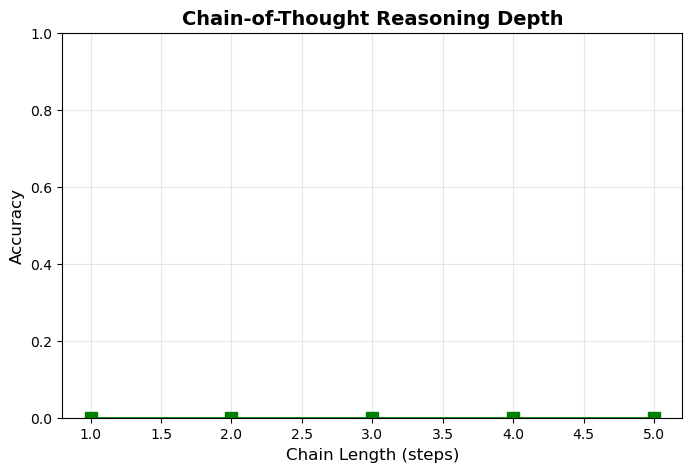


✓ Chain-of-thought test complete
  Depth 1: 0.000 accuracy
  Depth 2: 0.000 accuracy
  Depth 3: 0.000 accuracy
  Depth 4: 0.000 accuracy
  Depth 5: 0.000 accuracy


In [21]:
print("Testing chain-of-thought reasoning...\n")

# Test reasoning with 2-5 steps
cot_results = evaluate_cot_depth(
    model=model,
    max_depth=5,  # Test up to 5 steps
    num_samples=10,  # Fewer samples for speed
    device=device
)

# Plot results
depths = cot_results['depth']
accuracies = cot_results['accuracy']

plt.figure(figsize=(8, 5))
plt.plot(depths, accuracies, marker='s', color='green', linewidth=2, markersize=8)
plt.xlabel('Chain Length (steps)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Chain-of-Thought Reasoning Depth', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

print("\n✓ Chain-of-thought test complete")
for i, depth in enumerate(depths):
    print(f"  Depth {depth}: {accuracies[i]:.3f} accuracy")

## Test 3: Ablation Study - No Global Sync

What happens if we turn off the global synchronization layer?

In [22]:
print("Testing ablation: model without global sync...\n")

ablation_results = ablation_no_sync(
    vocab_size=vocab_size,
    distances=[64, 128],  # Shorter for quick test
    num_samples=20,
    device=device
)

print("\n✓ Ablation test complete")
print("Results:", ablation_results)

Testing ablation: model without global sync...


=== Ablation 1: No Global Sync ===
RSM MODEL CREATED
Vocabulary: 50,257 tokens
Hidden size: 128
Layers: 4
Attention heads: 4
Memory slots: 32
Chunk size: 256
Global sync: No

Parameters:
  Main model: 7,689,600
  Global sync: 0
  Total: 7,689,600
  Memory (float32): 29.3 MB
Testing distance=64...
RSM MODEL CREATED
Vocabulary: 50,257 tokens
Hidden size: 128
Layers: 4
Attention heads: 4
Memory slots: 32
Chunk size: 256
Global sync: No

Parameters:
  Main model: 7,689,600
  Global sync: 0
  Total: 7,689,600
  Memory (float32): 29.3 MB
Testing distance=64...
  Distance 64: 0.000 accuracy (0/20)
Testing distance=128...
  Distance 64: 0.000 accuracy (0/20)
Testing distance=128...
  Distance 128: 0.000 accuracy (0/20)

✓ Ablation test complete
Results: {64: {'accuracy': 0.0, 'correct': 0, 'total': 20}, 128: {'accuracy': 0.0, 'correct': 0, 'total': 20}}
  Distance 128: 0.000 accuracy (0/20)

✓ Ablation test complete
Results: {64: {'accuracy': 0.

## Test 4: Memory Retention Analysis

What information is stored in the memory slots over time?

In [ ]:
print("Analyzing memory retention...\n")

# Generate some random sequence (no batch dimension - the function adds it)
test_sequence = torch.randint(0, vocab_size, (256,), device=device)

# Analyze how memory changes
memory_analysis = analyze_memory_retention(
    model=model,
    sequence=test_sequence,
    device=device
)

# Average similarity across all memory slots over time
slot_names = list(memory_analysis.keys())
num_chunks = len(memory_analysis[slot_names[0]])

# Compute average similarity across all slots for each time step
avg_similarities = []
for t in range(num_chunks):
    sims_at_t = [memory_analysis[slot][t] for slot in slot_names]
    avg_similarities.append(np.mean(sims_at_t))

# Plot average memory retention over time
plt.figure(figsize=(10, 5))
plt.plot(range(num_chunks), avg_similarities, marker='o', linewidth=2)
plt.xlabel('Chunk Transition', fontsize=12)
plt.ylabel('Avg Cosine Similarity (memory retention)', fontsize=12)
plt.title('Memory State Retention Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ Memory analysis complete")
print(f"  Tracked {len(slot_names)} memory slots")
print(f"  {num_chunks} chunk transitions")
print(f"  Average retention: {np.mean(avg_similarities):.3f}")

Analyzing memory retention...



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices